# R33 — AUC-Scored Cascade BayesSearchCV for Referable Glaucoma

**Key insight from R32b**: The bilateral F1 scorer was too noisy (threshold sweep × CV folds)
causing BayesSearchCV to converge to degenerate boundary solutions (alpha=1.0, lr=0.0001).

**R33 fixes** (A + B + C):
- **A — Per-eye AUC scorer**: Smooth, threshold-free metric → well-behaved surrogate model
- **B — R28 warm-start**: After BayesSearchCV, also evaluate R28's known-good hyperparameters as challenger; keep whichever is better
- **C — Precision fix**: Wider `pos_weight` range [0.5, 3.5]; try both `mean_proba` and bilateral counting at eval stage

Pipeline per encoder:
1. PCA → MI selection → metadata + OD masking (same as R28/R31)
2. **BayesSearchCV** with `scoring='roc_auc'` (per-eye, smooth, threshold-free)
3. Challenger: evaluate R28 hyperparameters on same pipeline, keep best
4. 25-bag ensemble with winning hyperparams
5. Isotonic calibration → bilateral threshold sweep (max + mean proba) on val
6. Evaluate on test

In [6]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 1 — Imports
# ═══════════════════════════════════════════════════════════════════════
from __future__ import annotations
import json, time, warnings, ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from matplotlib.collections import LineCollection

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, cross_val_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, balanced_accuracy_score,
    confusion_matrix, classification_report, roc_curve,
    make_scorer,
)
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

import sys
sys.path.insert(0, str(Path.cwd() / 'src'))
from retina_embeddings_dataset import load_retina_embeddings_dataset

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
plt.style.use('seaborn-v0_8-whitegrid')
print('R33 imports OK')

R33 imports OK


In [7]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 2 — Configuration
# ═══════════════════════════════════════════════════════════════════════

DATASET_NAME = 'brset'
TASK         = 'increased_cup_disc'   # per-eye label used by Stage 1
RANDOM_SEED  = 42

from multiprocessing import cpu_count
CPU_COUNT = cpu_count()

# ─── Paths ────────────────────────────────────────────────────────
BASE_DIR     = Path.cwd()
FE_DIR       = BASE_DIR / 'artifacts' / 'brset_eda_fe'
EMBED_DIR    = BASE_DIR / 'data' / 'brset_embeddings'
LABELS_PATH  = EMBED_DIR / 'brset_labels' / 'labels_brset.csv'
RESULTS_DIR  = BASE_DIR / 'results' / 'brset_r33_auc_cascade_referable_glaucoma'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# R28 dir (for warm-start challenger and comparison)
R28_DIR = BASE_DIR / 'results' / 'brset_r28_fe_experiment' / 'r28_per_encoder'
R31_DIR = BASE_DIR / 'results' / 'brset_r31_cascade_referable_glaucoma' / 'r31_per_encoder'
R32_DIR_CMP = BASE_DIR / 'results' / 'brset_r32_e2e_cascade_referable_glaucoma' / 'r32_per_encoder'

# ─── Pipeline parameters (identical to R28/R31) ───────────────────
PCA_COMPONENTS       = 384
MI_SELECTION         = True
MI_PERCENTILE_THRESH = 0.15
MI_MIN_COMPONENTS    = 128

MLP_MAX_ITER   = 300          # ← R33: reduced from 400 (early stopping handles convergence)
MLP_PATIENCE   = 30

BAG_SEEDS           = [42, 123, 314]   # ← R33: 3 seeds (was 5) — 15 bags instead of 25
N_BAG_ARCH_VARIANTS = 5
N_BAGS = len(BAG_SEEDS) * N_BAG_ARCH_VARIANTS   # 15

THRESHOLD_GRID  = 151         # ← R33: reduced from 301 (sufficient precision for 3-digit threshold)
THRESHOLD_FLOOR = 0.05

# ─── BayesSearchCV parameters ────────────────────────────────────
ARCHITECTURE_OPTIONS = [
    (128,), (256,), (512,),
    (256, 128), (512, 256), (512, 128),
    (256, 128, 64), (512, 256, 128),
    (128, 64), (384, 192),
    (384, 192, 96),
]

SEARCH_SPACE = {
    'hidden_layer_sizes': Categorical(list(range(len(ARCHITECTURE_OPTIONS)))),
    'alpha': Real(1e-3, 1.0, prior='log-uniform'),
    'learning_rate_init': Real(1e-4, 2e-3, prior='log-uniform'),
    'batch_size': Categorical([64, 128, 256]),
    'pos_class_weight': Real(0.5, 3.5, prior='uniform'),
}

BAYES_N_ITER   = 25           # ← R33: reduced from 40 (AUC scorer is smooth → converges faster)
BAYES_CV_FOLDS = 3
BAYES_N_JOBS   = min(CPU_COUNT - 1, 6)

# ─── Clinical metadata (same 5 cols as R28) ──────────────────────
METADATA_COLS = {
    'age':      'numeric',
    'sex':      'passthrough',
    'diabetes': 'binary_yn',
    'exam_eye': 'binary',
    'camera':   'camera',
}

# ─── optic_disc masking (same as R28) ────────────────────────────
OD_P_MASK_BASE    = 0.50
OD_P_MASK_RANGE   = (0.35, 0.70)
OD_CORRUPT        = 0.10
OD_FEATURE_WEIGHT = 0.50
OD_MISS_WEIGHT    = 0.50
OD_TEST_P_MASK    = 0.25

# ─── Bilateral / referable threshold ─────────────────────────────
BILATERAL_MIN_EYES = 2

print(f'Results dir:     {RESULTS_DIR}')
print(f'Stage 1 task:    {TASK} (per-eye)')
print(f'Stage 2 rule:    ≥{BILATERAL_MIN_EYES} positive eyes → referable (PATIENT-LEVEL)')
print(f'BayesSearchCV:   {BAYES_N_ITER} iters, {BAYES_CV_FOLDS}-fold CV, scoring=roc_auc (per-eye)')
print(f'  Search space:  arch={len(ARCHITECTURE_OPTIONS)} options, α=[1e-3,1], lr=[1e-4,2e-3], bs=[64/128/256], w=[0.5,3.5]')
print(f'  Warm-start:    R28 challenger (evaluate R28 best params, keep better)')
print(f'Bagging: {len(BAG_SEEDS)} seeds × {N_BAG_ARCH_VARIANTS} variants = {N_BAGS}')
print(f'MLP: max_iter={MLP_MAX_ITER}, patience={MLP_PATIENCE}')
print(f'OD masking: base={OD_P_MASK_BASE:.0%}, range={OD_P_MASK_RANGE}, corrupt={OD_CORRUPT:.0%}')
print(f'Threshold grid: {THRESHOLD_GRID} points')

Results dir:     c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\brset_r33_auc_cascade_referable_glaucoma
Stage 1 task:    increased_cup_disc (per-eye)
Stage 2 rule:    ≥2 positive eyes → referable (PATIENT-LEVEL)
BayesSearchCV:   25 iters, 3-fold CV, scoring=roc_auc (per-eye)
  Search space:  arch=11 options, α=[1e-3,1], lr=[1e-4,2e-3], bs=[64/128/256], w=[0.5,3.5]
  Warm-start:    R28 challenger (evaluate R28 best params, keep better)
Bagging: 3 seeds × 5 variants = 15
MLP: max_iter=300, patience=30
OD masking: base=50%, range=(0.35, 0.7), corrupt=10%
Threshold grid: 151 points


In [8]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 3 — Load Data + FE Artifacts
# ═══════════════════════════════════════════════════════════════════════

splits = pd.read_csv(FE_DIR / 'splits_patient.csv')
splits['patient_id'] = splits['patient_id'].astype(str)

train_pids = set(splits[splits['split'] == 'train']['patient_id'])
val_pids   = set(splits[splits['split'] == 'val']['patient_id'])
test_pids  = set(splits[splits['split'] == 'test']['patient_id'])

assert len(train_pids & val_pids)  == 0
assert len(train_pids & test_pids) == 0
assert len(val_pids   & test_pids) == 0

labels_raw = pd.read_csv(LABELS_PATH)
labels_raw['patient_id'] = labels_raw['patient_id'].astype(str)
labels_raw = labels_raw.rename(columns={'patient_age': 'age', 'patient_sex': 'sex'})

embedding_files = sorted(EMBED_DIR.glob('Embeddings_*.csv'))

def build_referable_labels(df, task_col, min_eyes):
    pos_count = df[df[task_col] == 1].groupby('patient_id')[task_col].count()
    all_pids = df['patient_id'].unique()
    result = pd.Series(0, index=all_pids, name='referable_glaucoma')
    referable = pos_count[pos_count >= min_eyes].index
    result.loc[result.index.isin(referable)] = 1
    return result

_preview_df = labels_raw.dropna(subset=[TASK]).copy()
_preview_df['patient_id'] = _preview_df['patient_id'].astype(str)
_ref = build_referable_labels(_preview_df, TASK, BILATERAL_MIN_EYES)
_ref_train = _ref[_ref.index.isin(train_pids)]
_ref_val   = _ref[_ref.index.isin(val_pids)]
_ref_test  = _ref[_ref.index.isin(test_pids)]

print(f'Patient split:   {len(train_pids)} train / {len(val_pids)} val / {len(test_pids)} test')
print(f'Embedding files: {len(embedding_files)}')
print(f'\nReferable glaucoma (≥{BILATERAL_MIN_EYES} eyes with {TASK}=1):')
print(f'  Train: {_ref_train.sum():>4}/{len(_ref_train)} ({_ref_train.mean():.1%})')
print(f'  Val:   {_ref_val.sum():>4}/{len(_ref_val)} ({_ref_val.mean():.1%})')
print(f'  Test:  {_ref_test.sum():>4}/{len(_ref_test)} ({_ref_test.mean():.1%})')

Patient split:   5796 train / 1023 val / 1705 test
Embedding files: 7

Referable glaucoma (≥2 eyes with increased_cup_disc=1):
  Train:  789/5796 (13.6%)
  Val:    157/1023 (15.3%)
  Test:   229/1705 (13.4%)


In [9]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 4 — Helper Functions
# ═══════════════════════════════════════════════════════════════════════

def short_name(path):
    stem = Path(path).stem
    for s in ['Embeddings_brset_', 'Embeddings_']:
        stem = stem.replace(s, '')
    return stem


def make_sample_weights(y, pos_class_weight=1.0):
    y = np.asarray(y)
    w = np.where(y == 1, float(pos_class_weight), 1.0).astype(np.float32)
    mean_w = w.mean()
    if mean_w > 0:
        w /= mean_w
    return w


def mi_select_features(X_train, y_train, X_others,
                       percentile_thresh=0.15, min_components=128,
                       random_state=42):
    mi_scores = mutual_info_classif(
        X_train, y_train, discrete_features=False,
        n_neighbors=5, random_state=random_state,
    )
    threshold = np.percentile(mi_scores, percentile_thresh * 100)
    mask = mi_scores >= threshold
    if mask.sum() < min_components:
        top_k = np.argsort(mi_scores)[-min_components:]
        mask = np.zeros(len(mi_scores), dtype=bool)
        mask[top_k] = True
    X_train_sel = X_train[:, mask]
    X_others_sel = [X[:, mask] for X in X_others]
    return X_train_sel, X_others_sel, mask, mi_scores


def encode_metadata(df, metadata_cols, fit_stats=None):
    if fit_stats is None:
        fit_stats = {}
    meta_parts = []
    for col, dtype in metadata_cols.items():
        if col not in df.columns:
            continue
        vals = df[col].copy()
        if dtype == 'numeric':
            vals = pd.to_numeric(vals, errors='coerce')
            if 'median_' + col not in fit_stats:
                fit_stats['median_' + col] = float(vals.median())
            vals = vals.fillna(fit_stats['median_' + col])
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dtype == 'binary':
            vals = pd.to_numeric(vals, errors='coerce').fillna(1)
            vals = (vals - 1).clip(0, 1)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dtype == 'passthrough':
            vals = pd.to_numeric(vals, errors='coerce').fillna(0)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dtype == 'binary_yn':
            vals = vals.astype(str).str.lower().map({'yes': 1.0, 'no': 0.0}).fillna(0.0)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dtype == 'camera':
            vals = vals.astype(str).map({'Canon CR': 0.0, 'NIKON NF5050': 1.0}).fillna(0.0)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
    if not meta_parts:
        return np.zeros((len(df), 0), dtype=np.float32), fit_stats
    return np.hstack(meta_parts), fit_stats


def make_wider(arch, factor=1.5):
    return tuple(max(64, int(x * factor)) for x in arch)
def make_deeper(arch):
    return arch + (max(64, arch[-1] // 2),)
def make_narrower(arch, factor=0.67):
    return tuple(max(64, int(x * factor)) for x in arch)
def make_shallower(arch):
    if len(arch) > 1: return arch[:-1]
    return (max(64, arch[0] // 2),)


def _bin_od(series):
    return (pd.to_numeric(series, errors='coerce') == 2).astype(np.float32).to_numpy()

def _mask_od(od_series, p_mask, rng, p_corrupt=0.0):
    od = _bin_od(od_series)
    if p_mask >= 1.0:
        miss = np.ones(len(od), dtype=bool)
    elif p_mask > 0:
        miss = rng.random(len(od)) < p_mask
    else:
        miss = np.zeros(len(od), dtype=bool)
    od_m = od.copy()
    od_m[miss] = 0.0
    if p_corrupt and p_corrupt > 0:
        corrupt = (~miss) & (rng.random(len(od)) < p_corrupt)
        od_m[corrupt] = 1.0 - od_m[corrupt]
    return od_m.reshape(-1, 1), miss.astype(np.float32).reshape(-1, 1)

def _apply_od_weights(X_s, od_w, miss_w):
    if X_s.shape[1] < 2: return X_s
    if od_w != 1.0: X_s[:, -2] *= od_w
    if miss_w != 1.0: X_s[:, -1] *= miss_w
    return X_s


# ─── Bilateral cascade logic ──────────────────────────────────────
def bilateral_patient_predictions(pids, proba, threshold, min_eyes=2):
    df = pd.DataFrame({'patient_id': pids, 'proba': proba,
                        'pred_pos': (proba >= threshold).astype(int)})
    agg = df.groupby('patient_id').agg(
        n_positive=('pred_pos', 'sum'),
        n_images=('pred_pos', 'count'),
        max_proba=('proba', 'max'),
        mean_proba=('proba', 'mean'),
    )
    agg['referable_pred'] = (agg['n_positive'] >= min_eyes).astype(int)
    return agg


def sweep_bilateral_threshold(pids, proba, y_referable_patient,
                              min_eyes=2, grid_size=301, floor=0.05):
    thresholds = np.linspace(floor, 0.99, grid_size)
    best_f1, best_t = 0.0, 0.5
    all_res = []
    for t in thresholds:
        agg = bilateral_patient_predictions(pids, proba, t, min_eyes)
        com = agg.index.intersection(y_referable_patient.index)
        if len(com) == 0: continue
        yt = y_referable_patient.loc[com].values
        yh = agg.loc[com, 'referable_pred'].values
        f1 = f1_score(yt, yh, zero_division=0) if yh.sum() > 0 else 0.0
        prec = precision_score(yt, yh, zero_division=0)
        rec  = recall_score(yt, yh, zero_division=0)
        all_res.append({'threshold': t, 'f1': f1, 'precision': prec, 'recall': rec,
                        'n_predicted_pos': int(yh.sum())})
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1, pd.DataFrame(all_res)


# ─── MLPWrapper for BayesSearchCV ─────────────────────────────────
class MLPCascadeWrapper(BaseEstimator, ClassifierMixin):
    """
    Wraps MLPClassifier for BayesSearchCV with per-eye AUC scoring.
    R33: No patient-level logic inside the wrapper — bilateral cascade
    is applied only at the final eval stage (Stage D).
    """
    _estimator_type = "classifier"

    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        tags.estimator_type = "classifier"
        return tags

    def __init__(self, hidden_layer_sizes=0, alpha=0.01,
                 learning_rate_init=0.001, batch_size=64,
                 pos_class_weight=1.0, max_iter=300,
                 early_stopping=True, validation_fraction=0.15,
                 n_iter_no_change=30, random_state=42):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.alpha = alpha
        self.learning_rate_init = learning_rate_init
        self.batch_size = batch_size
        self.pos_class_weight = pos_class_weight
        self.max_iter = max_iter
        self.early_stopping = early_stopping
        self.validation_fraction = validation_fraction
        self.n_iter_no_change = n_iter_no_change
        self.random_state = random_state
        self._mlp = None

    def _get_architecture(self):
        if isinstance(self.hidden_layer_sizes, int):
            return ARCHITECTURE_OPTIONS[self.hidden_layer_sizes]
        return self.hidden_layer_sizes

    def fit(self, X, y, sample_weight=None):
        arch = self._get_architecture()
        self._mlp = MLPClassifier(
            hidden_layer_sizes=arch, alpha=self.alpha,
            learning_rate='adaptive',
            learning_rate_init=self.learning_rate_init,
            batch_size=self.batch_size, max_iter=self.max_iter,
            early_stopping=self.early_stopping,
            validation_fraction=self.validation_fraction,
            n_iter_no_change=self.n_iter_no_change,
            random_state=self.random_state,
        )
        sw = make_sample_weights(y, pos_class_weight=self.pos_class_weight)
        self._mlp.fit(X, y, sample_weight=sw)
        self.classes_ = self._mlp.classes_
        return self

    def predict(self, X): return self._mlp.predict(X)
    def predict_proba(self, X): return self._mlp.predict_proba(X)


def load_r28_hyperparams(sname, r28_dir):
    """Load R28's best hyperparameters for a given encoder as a challenger config."""
    for d in sorted(r28_dir.iterdir()):
        hp_file = d / 'hyperparameters.json'
        if hp_file.exists():
            with open(hp_file) as f:
                hp = json.load(f)
            if hp.get('embedding', '') == sname:
                arch_str = hp.get('architecture', '(128,)')
                try:
                    arch_tuple = ast.literal_eval(arch_str)
                except:
                    arch_tuple = (128,)
                arch_idx = None
                for i, opt in enumerate(ARCHITECTURE_OPTIONS):
                    if opt == arch_tuple:
                        arch_idx = i
                        break
                if arch_idx is None:
                    arch_idx = 0
                return {
                    'hidden_layer_sizes': arch_idx,
                    'alpha': float(hp.get('alpha', 0.01)),
                    'learning_rate_init': float(hp.get('lr', 0.001)),
                    'batch_size': int(hp.get('batch_size', 64)),
                    'pos_class_weight': float(hp.get('pos_weight', 1.0)),
                    'cv_f1': float(hp.get('best_cv_f1', 0.0)),
                    'architecture': arch_tuple,
                }
    return None


def sweep_bilateral_threshold_multi(pids, proba, y_referable_patient,
                                    min_eyes=2, grid_size=151, floor=0.05):
    """
    Sweep bilateral threshold using BOTH counting (≥min_eyes) and mean_proba methods.
    Returns the best (threshold, f1, method, sweep_df) across both approaches.
    All evaluation is PATIENT-LEVEL.
    """
    thresholds = np.linspace(floor, 0.99, grid_size)
    best_f1, best_t, best_method = 0.0, 0.5, 'bilateral'
    all_res = []

    # Method 1: Bilateral counting (original) — per-eye threshold → count ≥ min_eyes → patient label
    for t in thresholds:
        agg = bilateral_patient_predictions(pids, proba, t, min_eyes)
        com = agg.index.intersection(y_referable_patient.index)
        if len(com) == 0: continue
        yt = y_referable_patient.loc[com].values
        yh = agg.loc[com, 'referable_pred'].values
        f1 = f1_score(yt, yh, zero_division=0) if yh.sum() > 0 else 0.0
        prec = precision_score(yt, yh, zero_division=0)
        rec  = recall_score(yt, yh, zero_division=0)
        all_res.append({'method': 'bilateral', 'threshold': t, 'f1': f1,
                        'precision': prec, 'recall': rec, 'n_predicted_pos': int(yh.sum())})
        if f1 > best_f1:
            best_f1, best_t, best_method = f1, t, 'bilateral'

    # Method 2: Mean proba — patient score = mean of eye probabilities → threshold → patient label
    df_p = pd.DataFrame({'patient_id': pids, 'proba': proba})
    mean_agg = df_p.groupby('patient_id')['proba'].mean()
    for t in thresholds:
        yh_mean = (mean_agg >= t).astype(int)
        com = mean_agg.index.intersection(y_referable_patient.index)
        if len(com) == 0: continue
        yt = y_referable_patient.loc[com].values
        yh = yh_mean.loc[com].values
        f1 = f1_score(yt, yh, zero_division=0) if yh.sum() > 0 else 0.0
        prec = precision_score(yt, yh, zero_division=0)
        rec  = recall_score(yt, yh, zero_division=0)
        all_res.append({'method': 'mean_proba', 'threshold': t, 'f1': f1,
                        'precision': prec, 'recall': rec, 'n_predicted_pos': int(yh.sum())})
        if f1 > best_f1:
            best_f1, best_t, best_method = f1, t, 'mean_proba'

    return best_t, best_f1, best_method, pd.DataFrame(all_res)


# ─── Plotting ─────────────────────────────────────────────────────
def plot_confusion_matrix(cm, title, save_path=None, show=True):
    cm = np.asarray(cm)
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    cm_plot = np.ma.masked_where(cm <= 0, cm)
    vmax = int(cm.max()) if cm.size else 1
    norm = LogNorm(vmin=1, vmax=max(1, vmax))
    im = ax.imshow(cm_plot, cmap='viridis', interpolation='nearest', norm=norm)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label('Count (log)', fontsize=9)
    ax.set_title(title, fontsize=11, pad=12)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_xticks(range(cm.shape[1])); ax.set_yticks(range(cm.shape[0]))
    thresh = cm.max() / 2.0
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, f'{val}', ha='center', va='center',
                color='white' if val > thresh else 'black', fontsize=10, fontweight='bold')
    plt.tight_layout()
    if save_path: fig.savefig(save_path, dpi=160, bbox_inches='tight')
    if show: plt.show()
    else: plt.close(fig)


def plot_roc_curve(fpr, tpr, auc_val, title, save_path=None, show=True):
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    points = np.array([fpr, tpr]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap='plasma', norm=Normalize(0, 1))
    lc.set_array(fpr); lc.set_linewidth(2.6)
    ax.add_collection(lc)
    ax.plot([0,1],[0,1],'--', color='#666', lw=1.2, label='Chance')
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_title(f'{title}\nAUC = {auc_val:.3f}', fontsize=11, pad=12)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(loc='lower right', fontsize=9)
    fig.colorbar(lc, ax=ax, fraction=0.046, pad=0.04).set_label('FPR', fontsize=9)
    plt.tight_layout()
    if save_path: fig.savefig(save_path, dpi=160, bbox_inches='tight')
    if show: plt.show()
    else: plt.close(fig)


print(f'Helpers OK  (bilateral min eyes = {BILATERAL_MIN_EYES}, scorer = roc_auc, patient-level eval)')

Helpers OK  (bilateral min eyes = 2, scorer = roc_auc, patient-level eval)


## Per-Encoder Loop: BayesSearchCV (AUC) → R28 Challenger → Bagging → Bilateral Evaluation

For each encoder:
1. PCA + MI selection + metadata + OD masking (same as R28/R31)
2. **BayesSearchCV** with `scoring='roc_auc'` (per-eye, smooth, threshold-free)
3. **R28 Challenger**: evaluate R28's known-good hyperparameters; keep whichever gives higher CV AUC
4. 25-bag ensemble with winning hyperparams
5. Isotonic calibration → bilateral threshold sweep (bilateral counting + mean_proba) on val
6. Test evaluation + save artifacts

**R33 fixes** (vs R32b):
- `scoring='roc_auc'` replaces noisy bilateral F1 scorer → smooth surrogate surface
- No patient_id embedding in X → simpler code, no wrapper gymnastics
- Per-encoder `random_state = RANDOM_SEED + emb_idx`
- `pos_class_weight` range widened to [0.5, 3.5] → optimizer can reduce false positives
- R28 warm-start: after BayesSearchCV, also evaluate R28's best params → defender/challenger
- Dual aggregation: bilateral counting + mean_proba at Stage D

════════════════════════════════════════════════════════════════════════════════
R33 — AUC-Scored Cascade BayesSearchCV: Per-Eye AUC + R28 Challenger
════════════════════════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════════════════════════
[1/7] R33 — convnextv2_base_
════════════════════════════════════════════════════════════════════════════════
  PCA: 1024→384 (98.8% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  [BayesSearchCV] 25 iters, 3-fold patient-stratified CV
    Scoring: per-eye ROC AUC (smooth, threshold-free)
  ★ Bayes best CV AUC: 0.8974
    arch=(128, 64)  α=1.0000  lr=0.000100  bs=64  w=0.500
  ★ R28 challenger CV AUC: 0.8985  (arch=(128,)  w=4.071)
  → R28 challenger WINS by +0.0011 — using R28 params
  [Bagging] 15 models
  Stage C done: 15 MLPs trained
  Per-image proba range: val=[0.001, 0.999]  test=[0.001, 0.999]
  ★ Stage D: raw | bilateral | thr=0.495 | val_F1=0.7855
  TEST: F1

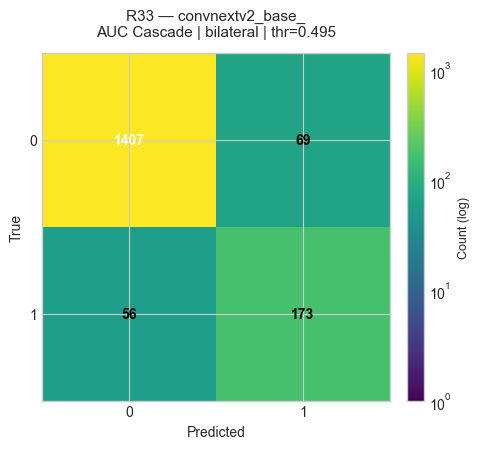

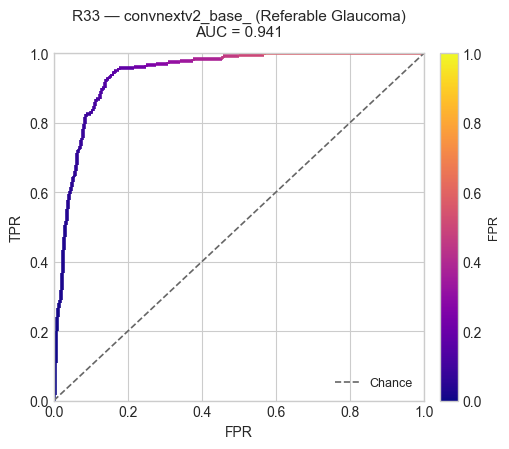


════════════════════════════════════════════════════════════════════════════════
[2/7] R33 — dinov3_convnext_base
════════════════════════════════════════════════════════════════════════════════
  PCA: 1024→384 (99.5% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  [BayesSearchCV] 25 iters, 3-fold patient-stratified CV
    Scoring: per-eye ROC AUC (smooth, threshold-free)
  ★ Bayes best CV AUC: 0.8810
    arch=(128,)  α=1.0000  lr=0.000263  bs=128  w=3.257
  ★ R28 challenger CV AUC: 0.8817  (arch=(128,)  w=2.463)
  → R28 challenger WINS by +0.0008 — using R28 params
  [Bagging] 15 models
  Stage C done: 15 MLPs trained
  Per-image proba range: val=[0.001, 0.982]  test=[0.001, 0.999]
  ★ Stage D: raw | bilateral | thr=0.457 | val_F1=0.7959
  TEST: F1=0.7597  Prec=0.7981  Rec=0.7249  AUC=0.9466  BalAcc=0.8482
  Val−Test gap: +0.0362
  Time: 1636s (27.3 min)
               precision    recall  f1-score   support

Not Referable      0.958     0.972     0.965      1476
    Refer

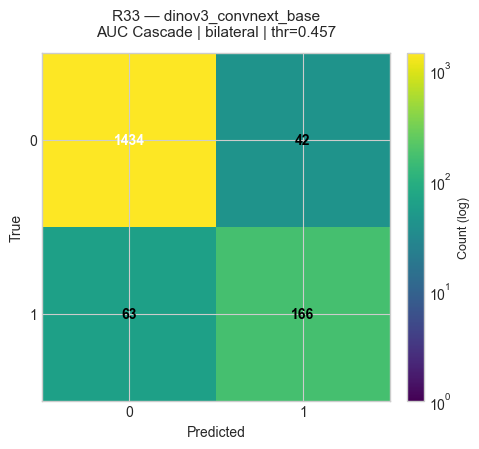

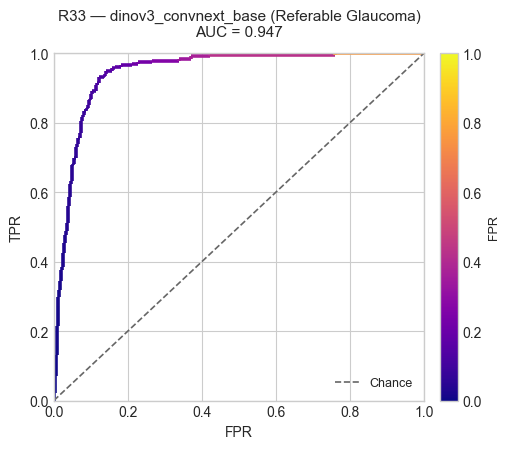


════════════════════════════════════════════════════════════════════════════════
[3/7] R33 — dinov3_vitb16
════════════════════════════════════════════════════════════════════════════════
  PCA: 768→384 (98.7% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  [BayesSearchCV] 25 iters, 3-fold patient-stratified CV
    Scoring: per-eye ROC AUC (smooth, threshold-free)
  ★ Bayes best CV AUC: 0.9085
    arch=(256,)  α=1.0000  lr=0.000100  bs=64  w=0.500
  ★ R28 challenger CV AUC: 0.9000  (arch=(128,)  w=2.449)
  → Bayes WINS by +0.0085 — using Bayes params
  [Bagging] 15 models
  Stage C done: 15 MLPs trained
  Per-image proba range: val=[0.001, 0.999]  test=[0.001, 0.999]
  ★ Stage D: raw | bilateral | thr=0.194 | val_F1=0.8307
  TEST: F1=0.7706  Prec=0.7864  Rec=0.7555  AUC=0.9454  BalAcc=0.8618
  Val−Test gap: +0.0601
  Time: 2570s (42.8 min)
               precision    recall  f1-score   support

Not Referable      0.962     0.968     0.965      1476
    Referable      0.786 

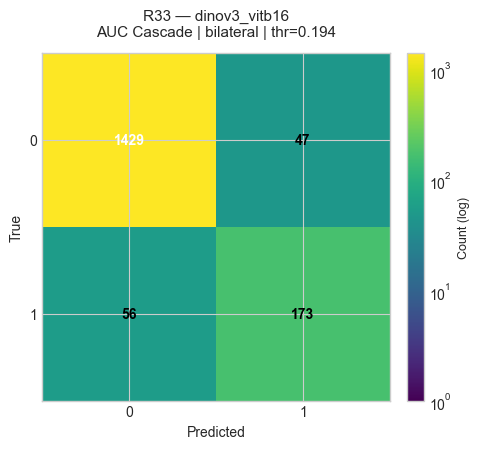

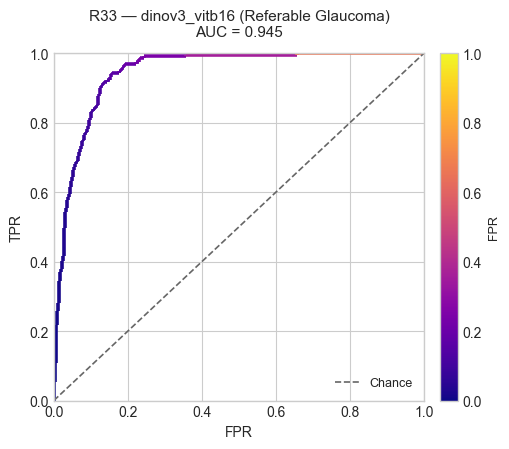


════════════════════════════════════════════════════════════════════════════════
[4/7] R33 — RETFound_dinov2_shanghai
════════════════════════════════════════════════════════════════════════════════
  PCA: 1024→384 (98.2% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  [BayesSearchCV] 25 iters, 3-fold patient-stratified CV
    Scoring: per-eye ROC AUC (smooth, threshold-free)


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 5 — Per-Encoder Loop with End-to-End BayesSearchCV
# ═══════════════════════════════════════════════════════════════════════

R33_DIR = RESULTS_DIR / 'r33_per_encoder'
R33_DIR.mkdir(parents=True, exist_ok=True)

print('═' * 80)
print('R33 — AUC-Scored Cascade BayesSearchCV: Per-Eye AUC + R28 Challenger')
print('═' * 80)

r33_results = []
t0_global = time.time()

for emb_idx, emb_path in enumerate(embedding_files):
    sname = short_name(emb_path)

    # ── Checkpoint: skip if results already exist ──────────────────
    chk_dir = R33_DIR / f'{emb_idx:02d}_{sname}'
    chk_hp  = chk_dir / 'hyperparameters.json'
    if chk_hp.exists():
        print(f'\n[{emb_idx+1}/{len(embedding_files)}] {sname} — CACHED, loading')
        with open(chk_hp) as _f:
            prev = json.load(_f)
        r33_results.append({
            'embedding': sname,
            'dim_raw': prev.get('emb_dim_raw', 0),
            'dim_pca': prev['pca_dim'],
            'dim_mi': prev['mi_selected'],
            'pca_var': prev['pca_var'],
            'r33_arch': prev['r33_architecture'],
            'r33_alpha': prev['r33_alpha'],
            'r33_lr': prev['r33_lr'],
            'r33_pos_weight': prev['r33_pos_weight'],
            'r33_batch_size': prev['r33_batch_size'],
            'r33_source': prev.get('r33_source', 'bayes'),
            'bayes_cv_auc': prev.get('bayes_cv_auc', 0.0),
            'r28_cv_auc': prev.get('r28_cv_auc', 0.0),
            'bilateral_method': prev.get('bilateral_method', 'bilateral'),
            'bilateral_threshold': prev['bilateral_threshold'],
            'val_referable_f1': prev['val_referable_f1'],
            'test_referable_f1': prev['test_referable_f1'],
            'test_referable_precision': prev['test_referable_precision'],
            'test_referable_recall': prev['test_referable_recall'],
            'test_referable_auc': prev['test_referable_auc'],
            'test_referable_bal_acc': prev['test_referable_bal_acc'],
            'n_test_patients': prev['n_test_patients'],
            'time_s': 0,
        })
        continue  # ← FIX: skip to next encoder when checkpoint exists

    print(f'\n{"═"*80}')
    print(f'[{emb_idx+1}/{len(embedding_files)}] R33 — {sname}')
    print(f'{"═"*80}')
    t0 = time.time()

    # ══════════════════════════════════════════════════════════════
    # STAGE A: Feature preparation (same as R28/R31)
    # ══════════════════════════════════════════════════════════════

    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME, embeddings_csv_path=emb_path,
        labels_csv_path=LABELS_PATH,
    )
    df = ds.df.copy()
    df['patient_id'] = df['patient_id'].astype(str)

    b_train = df[df['patient_id'].isin(train_pids)].dropna(subset=[TASK]).copy()
    b_val   = df[df['patient_id'].isin(val_pids)].dropna(subset=[TASK]).copy()
    b_test  = df[df['patient_id'].isin(test_pids)].dropna(subset=[TASK]).copy()

    X_tr_emb = b_train[ds.feature_cols].to_numpy(dtype=np.float32)
    X_va_emb = b_val[ds.feature_cols].to_numpy(dtype=np.float32)
    X_te_emb = b_test[ds.feature_cols].to_numpy(dtype=np.float32)

    yb_train = b_train[TASK].to_numpy(dtype=int)
    yb_val   = b_val[TASK].to_numpy(dtype=int)
    yb_test  = b_test[TASK].to_numpy(dtype=int)

    pids_tr = b_train['patient_id'].to_numpy()
    pids_va = b_val['patient_id'].to_numpy()
    pids_te = b_test['patient_id'].to_numpy()

    emb_dim_raw = X_tr_emb.shape[1]

    # PCA
    nc = min(PCA_COMPONENTS, emb_dim_raw, X_tr_emb.shape[0])
    pca = PCA(n_components=nc, random_state=RANDOM_SEED)
    X_tr_pca = pca.fit_transform(X_tr_emb)
    X_va_pca = pca.transform(X_va_emb)
    X_te_pca = pca.transform(X_te_emb)
    var_exp = pca.explained_variance_ratio_.sum()
    print(f'  PCA: {emb_dim_raw}→{nc} ({var_exp:.1%} var)')

    # MI Selection
    if MI_SELECTION:
        X_tr_sel, (X_va_sel, X_te_sel), mi_mask, _ = mi_select_features(
            X_tr_pca, yb_train, [X_va_pca, X_te_pca],
            percentile_thresh=MI_PERCENTILE_THRESH,
            min_components=MI_MIN_COMPONENTS,
            random_state=RANDOM_SEED,
        )
        n_kept = mi_mask.sum()
        print(f'  MI: {nc}→{n_kept}')
    else:
        X_tr_sel, X_va_sel, X_te_sel = X_tr_pca, X_va_pca, X_te_pca
        n_kept = nc

    # Metadata
    X_tr_meta, ms = encode_metadata(b_train, METADATA_COLS)
    X_va_meta, _  = encode_metadata(b_val, METADATA_COLS, fit_stats=ms)
    X_te_meta, _  = encode_metadata(b_test, METADATA_COLS, fit_stats=ms)
    meta_dim = X_tr_meta.shape[1]

    # OD masking
    rng_hp = np.random.default_rng(RANDOM_SEED)
    od_tr, miss_tr = _mask_od(b_train['optic_disc'], OD_P_MASK_BASE, rng_hp, OD_CORRUPT)
    X_tr_full = np.hstack([X_tr_sel, X_tr_meta, od_tr, miss_tr])
    ndim = X_tr_full.shape[1]
    print(f'  Dims: {n_kept} PCA + {meta_dim} meta + 2 OD = {ndim}')

    # Scale
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr_full)
    X_tr_s = _apply_od_weights(X_tr_s, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)

    # Val/test with P25 OD masking
    rng_v = np.random.default_rng(RANDOM_SEED + 7000)
    rng_t = np.random.default_rng(RANDOM_SEED + 9999)
    od_v, miss_v = _mask_od(b_val['optic_disc'],  OD_TEST_P_MASK, rng_v)
    od_t, miss_t = _mask_od(b_test['optic_disc'], OD_TEST_P_MASK, rng_t)

    X_va_s = scaler.transform(np.hstack([X_va_sel, X_va_meta, od_v, miss_v]))
    X_te_s = scaler.transform(np.hstack([X_te_sel, X_te_meta, od_t, miss_t]))
    X_va_s = _apply_od_weights(X_va_s.copy(), OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
    X_te_s = _apply_od_weights(X_te_s.copy(), OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)

    # ══════════════════════════════════════════════════════════════
    # STAGE B: BayesSearchCV with Per-Eye AUC Scoring (R33)
    # ══════════════════════════════════════════════════════════════

    # Patient-stratified CV: split by patient, not by image
    unique_train_pids = np.unique(pids_tr)
    pid_ref_labels = build_referable_labels(b_train, TASK, BILATERAL_MIN_EYES)
    pid_labels_for_cv = np.array([pid_ref_labels.get(p, 0) for p in unique_train_pids])

    pid_to_idx = {p: i for i, p in enumerate(unique_train_pids)}
    image_pid_indices = np.array([pid_to_idx[p] for p in pids_tr])

    skf = StratifiedKFold(n_splits=BAYES_CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    patient_cv_folds = list(skf.split(unique_train_pids, pid_labels_for_cv))

    image_cv_folds = []
    for pat_train_idx, pat_val_idx in patient_cv_folds:
        train_pids_fold = set(unique_train_pids[pat_train_idx])
        val_pids_fold   = set(unique_train_pids[pat_val_idx])
        img_train_idx = np.where(np.isin(pids_tr, list(train_pids_fold)))[0]
        img_val_idx   = np.where(np.isin(pids_tr, list(val_pids_fold)))[0]
        image_cv_folds.append((img_train_idx, img_val_idx))

    print(f'  [BayesSearchCV] {BAYES_N_ITER} iters, {BAYES_CV_FOLDS}-fold patient-stratified CV')
    print(f'    Scoring: per-eye ROC AUC (smooth, threshold-free)')

    # Per-encoder random state
    encoder_seed = RANDOM_SEED + emb_idx

    # R33: Use standard MLPCascadeWrapper (no pid column in X)
    base_model = MLPCascadeWrapper(
        max_iter=MLP_MAX_ITER, early_stopping=True,
        validation_fraction=0.15, n_iter_no_change=MLP_PATIENCE,
        random_state=encoder_seed,
    )

    # R33: Use per-eye AUC as scorer — smooth, threshold-free, low noise
    bayes = BayesSearchCV(
        estimator=base_model,
        search_spaces=SEARCH_SPACE,
        n_iter=BAYES_N_ITER,
        cv=image_cv_folds,
        n_jobs=1,
        scoring='roc_auc',   # ← KEY CHANGE: per-eye AUC instead of bilateral F1
        random_state=encoder_seed,
        verbose=0,
    )

    # R33: No pid column needed — pass clean X directly
    bayes.fit(X_tr_s, yb_train)

    bp = bayes.best_params_
    bayes_cv_auc = bayes.best_score_
    ai = bp.get('hidden_layer_sizes', 0)
    bayes_arch = ARCHITECTURE_OPTIONS[ai] if isinstance(ai, int) else ai
    bayes_alpha = bp['alpha']
    bayes_lr    = bp['learning_rate_init']
    bayes_bs    = bp['batch_size']
    bayes_w     = bp['pos_class_weight']

    print(f'  ★ Bayes best CV AUC: {bayes_cv_auc:.4f}')
    print(f'    arch={bayes_arch}  α={bayes_alpha:.4f}  lr={bayes_lr:.6f}  bs={bayes_bs}  w={bayes_w:.3f}')

    # ── R28 Challenger: evaluate R28's known-good hyperparameters ──
    r28_hp = load_r28_hyperparams(sname, R28_DIR)
    r28_cv_auc = 0.0
    param_source = 'bayes'

    if r28_hp is not None:
        r28_model = MLPCascadeWrapper(
            hidden_layer_sizes=r28_hp['hidden_layer_sizes'],
            alpha=r28_hp['alpha'],
            learning_rate_init=r28_hp['learning_rate_init'],
            batch_size=r28_hp['batch_size'],
            pos_class_weight=r28_hp['pos_class_weight'],
            max_iter=MLP_MAX_ITER, early_stopping=True,
            validation_fraction=0.15, n_iter_no_change=MLP_PATIENCE,
            random_state=encoder_seed,
        )
        # Evaluate R28 params on same CV folds
        r28_cv_scores = cross_val_score(
            r28_model, X_tr_s, yb_train,
            cv=image_cv_folds, scoring='roc_auc', n_jobs=1,
        )
        r28_cv_auc = r28_cv_scores.mean()
        print(f'  ★ R28 challenger CV AUC: {r28_cv_auc:.4f}  (arch={r28_hp["architecture"]}  w={r28_hp["pos_class_weight"]:.3f})')

        if r28_cv_auc > bayes_cv_auc:
            print(f'  → R28 challenger WINS by {r28_cv_auc - bayes_cv_auc:+.4f} — using R28 params')
            param_source = 'r28'
            barch = r28_hp['architecture']
            balpha = r28_hp['alpha']
            blr = r28_hp['learning_rate_init']
            bbs = r28_hp['batch_size']
            bw = r28_hp['pos_class_weight']
            bcv_auc = r28_cv_auc
        else:
            print(f'  → Bayes WINS by {bayes_cv_auc - r28_cv_auc:+.4f} — using Bayes params')
            barch = bayes_arch
            balpha = bayes_alpha
            blr = bayes_lr
            bbs = bayes_bs
            bw = bayes_w
            bcv_auc = bayes_cv_auc
    else:
        print(f'  ★ No R28 challenger found for {sname} — using Bayes params')
        barch = bayes_arch
        balpha = bayes_alpha
        blr = bayes_lr
        bbs = bayes_bs
        bw = bayes_w
        bcv_auc = bayes_cv_auc

    # ══════════════════════════════════════════════════════════════
    # STAGE C: 15-Bag Ensemble with Best Params
    # ══════════════════════════════════════════════════════════════

    barchs = [barch, make_wider(barch), make_deeper(barch),
              make_narrower(barch), make_shallower(barch)]
    print(f'  [Bagging] {N_BAGS} models')

    cal_p = {}
    cal_l = {}
    bag_va_proba = []
    bag_te_proba = []

    for s_idx, seed in enumerate(BAG_SEEDS):
        upids = np.unique(pids_tr)
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=seed)
        plm = b_train.groupby('patient_id')[TASK].max().to_dict()
        pl  = np.array([plm[p] for p in upids])
        ti, vi = next(sss.split(upids, pl))
        itr_pids = set(upids[ti])
        iva_pids = set(upids[vi])

        tr_m = np.isin(pids_tr, list(itr_pids))
        va_m = np.isin(pids_tr, list(iva_pids))

        rng_pm = np.random.default_rng(seed + 90000)
        pm_seed = float(rng_pm.uniform(OD_P_MASK_RANGE[0], OD_P_MASK_RANGE[1]))

        rng_it = np.random.default_rng(seed + 10000)
        od_it, miss_it = _mask_od(
            b_train.iloc[np.where(tr_m)[0]]['optic_disc'], pm_seed, rng_it, OD_CORRUPT)
        X_it = scaler.transform(np.hstack([X_tr_sel[tr_m], X_tr_meta[tr_m], od_it, miss_it]))
        X_it = _apply_od_weights(X_it, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
        y_it = yb_train[tr_m]

        rng_iv = np.random.default_rng(seed + 20000)
        od_iv, miss_iv = _mask_od(
            b_train.iloc[np.where(va_m)[0]]['optic_disc'], pm_seed, rng_iv, OD_CORRUPT)
        X_iv = scaler.transform(np.hstack([X_tr_sel[va_m], X_tr_meta[va_m], od_iv, miss_iv]))
        X_iv = _apply_od_weights(X_iv, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
        y_iv = yb_train[va_m]

        svp = []
        for a_idx, arch_v in enumerate(barchs):
            mlp = MLPClassifier(
                hidden_layer_sizes=arch_v, alpha=balpha,
                learning_rate='adaptive',
                learning_rate_init=blr, batch_size=bbs,
                max_iter=MLP_MAX_ITER, early_stopping=True,
                validation_fraction=0.15, n_iter_no_change=MLP_PATIENCE,
                random_state=seed + a_idx,
            )
            sw = make_sample_weights(y_it, bw)
            mlp.fit(X_it, y_it, sample_weight=sw)

            svp.append(mlp.predict_proba(X_iv)[:, 1])
            bag_va_proba.append(mlp.predict_proba(X_va_s)[:, 1])
            bag_te_proba.append(mlp.predict_proba(X_te_s)[:, 1])

        cal_p[seed] = np.mean(svp, axis=0)
        cal_l[seed] = y_iv

    # ── Calibration ───────────────────────────────────────────────
    cp = np.concatenate([cal_p[s] for s in BAG_SEEDS])
    cl = np.concatenate([cal_l[s] for s in BAG_SEEDS])
    iso = IsotonicRegression(y_min=0.001, y_max=0.999, out_of_bounds='clip')
    iso.fit(cp, cl)

    avg_va_raw = np.mean(bag_va_proba, axis=0)
    avg_te_raw = np.mean(bag_te_proba, axis=0)
    avg_va_cal = iso.predict(avg_va_raw)
    avg_te_cal = iso.predict(avg_te_raw)

    print(f'  Stage C done: {N_BAGS} MLPs trained')
    print(f'  Per-image proba range: val=[{avg_va_cal.min():.3f}, {avg_va_cal.max():.3f}]  '
          f'test=[{avg_te_cal.min():.3f}, {avg_te_cal.max():.3f}]')

    # ══════════════════════════════════════════════════════════════
    # STAGE D: Bilateral Threshold Sweep on Val → Test (R33: multi-method)
    # ══════════════════════════════════════════════════════════════

    ref_val  = build_referable_labels(b_val, TASK, BILATERAL_MIN_EYES)
    ref_test = build_referable_labels(b_test, TASK, BILATERAL_MIN_EYES)

    best_overall_f1 = 0.0
    best_overall_t  = 0.5
    best_pt = 'calibrated'
    best_agg_method = 'bilateral'

    for pt_name, va_proba, te_proba in [
        ('calibrated', avg_va_cal, avg_te_cal),
        ('raw', avg_va_raw, avg_te_raw),
    ]:
        # R33: Use multi-method sweep (bilateral + mean_proba)
        bt, bf1, bmethod, sweep_df = sweep_bilateral_threshold_multi(
            pids_va, va_proba, ref_val,
            min_eyes=BILATERAL_MIN_EYES,
            grid_size=THRESHOLD_GRID,
            floor=THRESHOLD_FLOOR,
        )
        if bf1 > best_overall_f1:
            best_overall_f1 = bf1
            best_overall_t  = bt
            best_pt = pt_name
            best_agg_method = bmethod

    print(f'  ★ Stage D: {best_pt} | {best_agg_method} | thr={best_overall_t:.3f} | val_F1={best_overall_f1:.4f}')

    # ── Evaluate on TEST ──────────────────────────────────────────
    te_proba_use = avg_te_cal if best_pt == 'calibrated' else avg_te_raw
    va_proba_use = avg_va_cal if best_pt == 'calibrated' else avg_va_raw

    # R33: Apply the winning aggregation method
    if best_agg_method == 'mean_proba':
        # Mean-proba aggregation
        df_te_p = pd.DataFrame({'patient_id': pids_te, 'proba': te_proba_use})
        mean_te = df_te_p.groupby('patient_id')['proba'].mean()
        com = mean_te.index.intersection(ref_test.index)
        yt = ref_test.loc[com].values
        yh = (mean_te.loc[com] >= best_overall_t).astype(int).values
        yp = mean_te.loc[com].values
        # Also compute bilateral agg for artifact saving
        test_agg = bilateral_patient_predictions(pids_te, te_proba_use, best_overall_t, BILATERAL_MIN_EYES)
    else:
        # Standard bilateral counting
        test_agg = bilateral_patient_predictions(pids_te, te_proba_use, best_overall_t, BILATERAL_MIN_EYES)
        com = test_agg.index.intersection(ref_test.index)
        yt = ref_test.loc[com].values
        yh = test_agg.loc[com, 'referable_pred'].values
        yp = test_agg.loc[com, 'max_proba'].values

    test_f1   = float(f1_score(yt, yh, zero_division=0))
    test_prec = float(precision_score(yt, yh, zero_division=0))
    test_rec  = float(recall_score(yt, yh, zero_division=0))
    test_auc  = float(roc_auc_score(yt, yp)) if len(np.unique(yt)) > 1 else 0.0
    test_ba   = float(balanced_accuracy_score(yt, yh))

    elapsed = time.time() - t0

    print(f'  TEST: F1={test_f1:.4f}  Prec={test_prec:.4f}  Rec={test_rec:.4f}  '
          f'AUC={test_auc:.4f}  BalAcc={test_ba:.4f}')
    print(f'  Val−Test gap: {best_overall_f1 - test_f1:+.4f}')
    print(f'  Time: {elapsed:.0f}s ({elapsed/60:.1f} min)')

    # ── Save artifacts ────────────────────────────────────────────
    out_dir = R33_DIR / f'{emb_idx:02d}_{sname}'
    out_dir.mkdir(parents=True, exist_ok=True)

    cm = confusion_matrix(yt, yh)
    rep = classification_report(yt, yh, digits=3,
                                target_names=['Not Referable', 'Referable'])
    print(rep)

    pd.DataFrame(cm).to_csv(out_dir / 'confusion_matrix.csv', index=False)
    (out_dir / 'classification_report.txt').write_text(rep, encoding='utf-8')

    fpr, tpr, _ = roc_curve(yt, yp)
    pd.DataFrame({'fpr': fpr, 'tpr': tpr}).to_csv(out_dir / 'roc_curve.csv', index=False)

    pd.DataFrame({
        'patient_id': com,
        'y_true_referable': yt,
        'y_pred_referable': yh,
        'max_proba': yp,
        'n_positive_eyes': test_agg.loc[com, 'n_positive'].values,
        'n_images': test_agg.loc[com, 'n_images'].values,
    }).to_csv(out_dir / 'patient_predictions.csv', index=False)

    pd.DataFrame({
        'image_id': b_test['image_id'].values,
        'patient_id': pids_te,
        'y_true_eye': yb_test,
        'proba_calibrated': avg_te_cal,
        'proba_raw': avg_te_raw,
        'pred_positive_eye': (te_proba_use >= best_overall_t).astype(int),
    }).to_csv(out_dir / 'image_predictions.csv', index=False)

    _, _, _, sweep_final = sweep_bilateral_threshold_multi(
        pids_va, va_proba_use, ref_val,
        min_eyes=BILATERAL_MIN_EYES, grid_size=THRESHOLD_GRID, floor=THRESHOLD_FLOOR)
    sweep_final.to_csv(out_dir / 'bilateral_threshold_sweep.csv', index=False)

    hp_save = {
        'track': 'R33', 'embedding': sname,
        'r33_architecture': str(barch), 'r33_alpha': float(balpha),
        'r33_lr': float(blr), 'r33_batch_size': int(bbs),
        'r33_pos_weight': float(bw),
        'r33_source': param_source,
        'bayes_cv_auc': float(bayes_cv_auc),
        'r28_cv_auc': float(r28_cv_auc),
        'pca_dim': nc, 'mi_selected': int(n_kept), 'pca_var': float(var_exp),
        'emb_dim_raw': emb_dim_raw, 'ndim': ndim,
        'n_bags': N_BAGS,
        'bilateral_min_eyes': BILATERAL_MIN_EYES,
        'bilateral_method': best_agg_method,
        'bilateral_threshold': float(best_overall_t),
        'proba_type': best_pt,
        'val_referable_f1': float(best_overall_f1),
        'test_referable_f1': test_f1,
        'test_referable_precision': test_prec,
        'test_referable_recall': test_rec,
        'test_referable_auc': test_auc,
        'test_referable_bal_acc': test_ba,
        'n_test_patients': int(len(com)),
    }
    with open(out_dir / 'hyperparameters.json', 'w') as f:
        json.dump(hp_save, f, indent=2)

    plot_confusion_matrix(cm,
        title=f'R33 — {sname}\nAUC Cascade | {best_agg_method} | thr={best_overall_t:.3f}',
        save_path=out_dir / 'confusion_matrix.png', show=True)
    plot_roc_curve(fpr, tpr, test_auc,
        title=f'R33 — {sname} (Referable Glaucoma)',
        save_path=out_dir / 'roc_curve.png', show=True)

    r33_results.append({
        'embedding': sname,
        'dim_raw': emb_dim_raw, 'dim_pca': nc, 'dim_mi': int(n_kept),
        'pca_var': float(var_exp),
        'r33_arch': str(barch), 'r33_alpha': float(balpha),
        'r33_lr': float(blr), 'r33_pos_weight': float(bw),
        'r33_batch_size': int(bbs),
        'r33_source': param_source,
        'bayes_cv_auc': float(bayes_cv_auc),
        'r28_cv_auc': float(r28_cv_auc),
        'bilateral_method': best_agg_method,
        'bilateral_threshold': float(best_overall_t),
        'val_referable_f1': float(best_overall_f1),
        'test_referable_f1': test_f1,
        'test_referable_precision': test_prec,
        'test_referable_recall': test_rec,
        'test_referable_auc': test_auc,
        'test_referable_bal_acc': test_ba,
        'n_test_patients': int(len(com)),
        'time_s': float(elapsed),
    })

total = time.time() - t0_global
print(f'\n{"═"*80}')
print(f'R33 complete! Total: {total:.0f}s ({total/60:.1f} min)')
print(f'{"═"*80}')

r33_df = pd.DataFrame(r33_results).sort_values('test_referable_f1', ascending=False)
r33_df.to_csv(R33_DIR / 'r33_summary.csv', index=False)

print('\n── R33 Per-Encoder Summary (sorted by Test Referable F1) ──')
show_cols = ['embedding', 'r33_source', 'bayes_cv_auc', 'r28_cv_auc',
             'val_referable_f1', 'test_referable_f1',
             'test_referable_precision', 'test_referable_recall',
             'test_referable_auc', 'bilateral_method', 'bilateral_threshold',
             'r33_pos_weight', 'r33_arch']
print(r33_df[[c for c in show_cols if c in r33_df.columns]].to_string(index=False))

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 6 — R33 vs R31 vs R32 Comparison
# ═══════════════════════════════════════════════════════════════════════

print('═' * 80)
print('R33 vs R31 vs R32 — Referable Glaucoma Comparison')
print('═' * 80)

# Load R31 summary
r31_path = R31_DIR / 'r31_summary.csv'
r31_loaded = pd.read_csv(r31_path) if r31_path.exists() else pd.DataFrame()

# Load R32 summary
r32_path = R32_DIR_CMP / 'r32_summary.csv'
r32_loaded = pd.read_csv(r32_path) if r32_path.exists() else pd.DataFrame()

# Load R29 summary
r29_path = BASE_DIR / 'results' / 'brset_r29_referable_glaucoma' / 'r29_per_encoder' / 'r29_summary.csv'
r29_loaded = pd.read_csv(r29_path) if r29_path.exists() else pd.DataFrame()

comparison_rows = []
for _, row in r33_df.iterrows():
    enc = row['embedding']
    comp = {'embedding': enc,
            'R33_f1': row['test_referable_f1'],
            'R33_prec': row['test_referable_precision'],
            'R33_rec': row['test_referable_recall'],
            'R33_auc': row['test_referable_auc'],
            'R33_source': row.get('r33_source', ''),
            'R33_method': row.get('bilateral_method', ''),
            'R33_pos_w': row['r33_pos_weight']}

    # R31
    if not r31_loaded.empty:
        m31 = r31_loaded[r31_loaded['embedding'] == enc]
        if not m31.empty:
            comp['R31_f1']  = m31.iloc[0]['test_referable_f1']
            comp['R31_pos_w'] = m31.iloc[0].get('r28_pos_weight', np.nan)

    # R32
    if not r32_loaded.empty:
        m32 = r32_loaded[r32_loaded['embedding'] == enc]
        if not m32.empty:
            comp['R32_f1']  = m32.iloc[0]['test_referable_f1']

    # R29
    if not r29_loaded.empty:
        for fc in ['test_f1', 'f1_P25', 'f1']:
            if fc in r29_loaded.columns:
                m29 = r29_loaded[r29_loaded['embedding'] == enc]
                if not m29.empty:
                    comp['R29_f1'] = m29.iloc[0][fc]
                break

    comparison_rows.append(comp)

comp_df = pd.DataFrame(comparison_rows)
print(comp_df.to_string(index=False))

# Summary
best_r33 = r33_df['test_referable_f1'].max()
best_r33_enc = r33_df.loc[r33_df['test_referable_f1'].idxmax(), 'embedding']

print(f'\n── Best F1 per track ──')
print(f'  R33 (AUC cascade):  {best_r33:.4f}  ({best_r33_enc})')
if not r31_loaded.empty:
    best_r31 = r31_loaded['test_referable_f1'].max()
    best_r31_enc = r31_loaded.loc[r31_loaded['test_referable_f1'].idxmax(), 'embedding']
    print(f'  R31 (cascade):      {best_r31:.4f}  ({best_r31_enc})')
if not r32_loaded.empty:
    best_r32 = r32_loaded['test_referable_f1'].max()
    best_r32_enc = r32_loaded.loc[r32_loaded['test_referable_f1'].idxmax(), 'embedding']
    print(f'  R32 (bilateral F1): {best_r32:.4f}  ({best_r32_enc})')
if not r31_loaded.empty:
    print(f'  R33 vs R31 delta: {best_r33 - best_r31:+.4f}')

# How many encoders meet 0.80?
n_above = (r33_df['test_referable_f1'] >= 0.80).sum()
print(f'\n  Encoders meeting F1 ≥ 0.80 target: {n_above}/{len(r33_df)}')
if n_above > 0:
    above = r33_df[r33_df['test_referable_f1'] >= 0.80]
    for _, r in above.iterrows():
        print(f'    ✓ {r["embedding"]}: F1={r["test_referable_f1"]:.4f}  (source={r.get("r33_source","")}, method={r.get("bilateral_method","")})')
else:
    # Show top 3 closest
    top3 = r33_df.nlargest(3, 'test_referable_f1')
    print('  Top 3 closest:')
    for _, r in top3.iterrows():
        print(f'    {r["embedding"]}: F1={r["test_referable_f1"]:.4f}  (gap={0.80 - r["test_referable_f1"]:+.4f})')

════════════════════════════════════════════════════════════════════════════════
R32 vs R31 vs R29 — Referable Glaucoma Comparison
════════════════════════════════════════════════════════════════════════════════
               embedding   R32_f1  R32_prec  R32_rec  R32_auc  R32_pos_w   R31_f1  R31_pos_w   R29_f1
           dinov3_vitb16 0.804301  0.792373 0.816594 0.947918   2.524259 0.800885   2.448675 0.721382
RETFound_dinov2_shanghai 0.782979  0.763485 0.803493 0.942104   2.524259 0.743494   2.908782 0.642241
        convnextv2_base_ 0.771855  0.754167 0.790393 0.947119   1.603808 0.744467   4.070851 0.698413
               vit_base_ 0.742358  0.742358 0.742358 0.934042   4.615408 0.699248   2.620812 0.661844
    dinov3_convnext_base 0.737089  0.796954 0.685590 0.942817   4.615408 0.764045   2.462905 0.687161
   RETFound_mae_shanghai 0.709677  0.751220 0.672489 0.937091   1.000000 0.728538   1.000000 0.642398
  RETFound_mae_natureCFP 0.692841  0.735294 0.655022 0.926569   4.344745 0